In [21]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import seaborn as sns
import pandas as pd
import os
os.environ["OMP_NUM_THREADS"] = "1"

In [22]:
iris = load_iris()

print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [23]:
X= iris.data
y = iris.target

<Axes: >

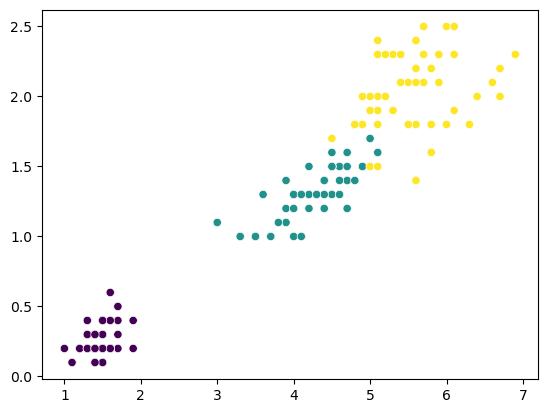

In [24]:
#visualizing the data
sns.scatterplot(x=X[:,2],y=X[:,3], c=y)

In [25]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

scaled_X

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [37]:
#optional - dimensionality reduction using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_X = pca.fit_transform(scaled_X)

In [38]:
#elbow method to find the optimal number of clusters
wcss = []

for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(pca_X)
    wcss.append(kmeans.inertia_)

c:\Users\sc790\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sc790\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sc790\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\sc790\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

In [39]:
wcss

[574.8792432000103,
 197.4038160454128,
 166.04203950421905,
 89.51333472314349,
 66.21951118837322,
 58.03403885341187,
 53.035354286843024,
 44.35132357949797,
 36.563972918774596,
 28.5288380559278]

<Axes: >

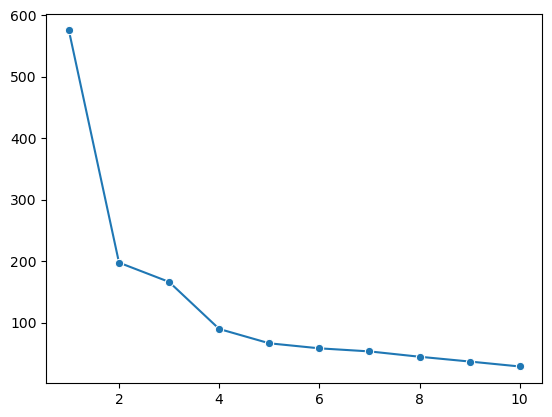

In [40]:
sns.lineplot(x=range(1,11), y=wcss,marker='o')

c:\Users\sc790\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

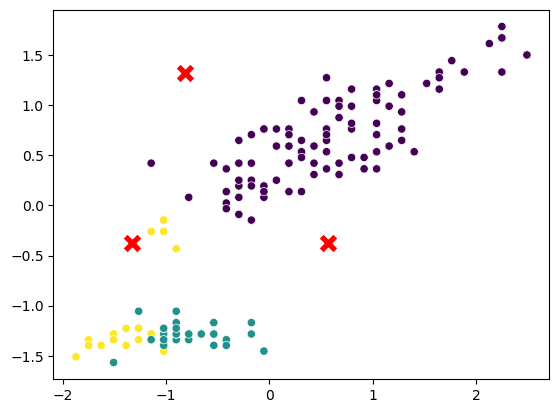

In [45]:
#without PCA
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(scaled_X)

sns.scatterplot(x=scaled_X[:,0],y=scaled_X[:,2], c=labels)
sns.scatterplot(x= kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1], s=200, c='red', marker='X')

c:\Users\sc790\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: >

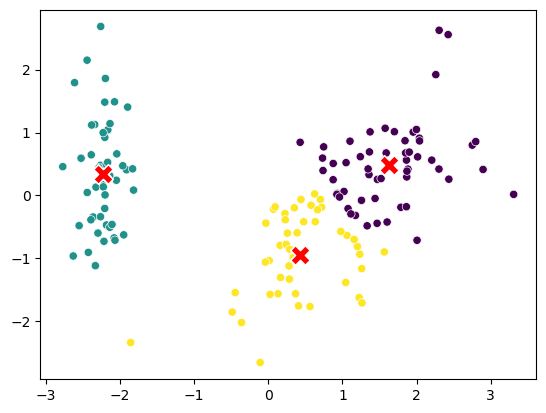

In [43]:
#kmeans
kmeans = KMeans(n_clusters=3, random_state=10)
labels = kmeans.fit_predict(pca_X)

sns.scatterplot(x=pca_X[:,0],y=pca_X[:,1], c=labels)
sns.scatterplot(x= kmeans.cluster_centers_[:,0],y=kmeans.cluster_centers_[:,1], s=200, c='red', marker='X')